# Question 2: Vision in the Real World – Indian Currency Classification

## Part A

### 2A.1.a

Considering input for layer 1 $x_1$  $\in$ $R^{3\times128\times128}$, 

let $h_{in} = 128$ and $h_{out} = 128$

$h_{out} = \lfloor (h_{in} - k + 2p)/(s) \rfloor + 1$ 

$\implies h_{out} = \lfloor (128 - 3 + 2)/(2) \rfloor + 1$

$\implies h_{out} = 64$

Similarly, 

$w_{out} = \lfloor (w_{in} - k + 2p)/(s) \rfloor + 1$ 

$\implies w_{out} = \lfloor (128 - 3 + 2)/(2) \rfloor + 1$

$\implies w_{out} = 64$

Hence output $x_2$ $\in$ $R^{32\times64\times64}$ 


### 2A.1.b

Considering input for layer 2 $x_2$  $\in$ $R^{32\times64\times64}$, 

let $h_{in} = 64$ and $h_{out} = 64$

$h_{out} = \lfloor (h_{in} - k + 2p)/(s) \rfloor + 1$ 

$\implies h_{out} = \lfloor (64 - 3 + 2)/(1) \rfloor + 1$

$\implies h_{out} = 64$

Similarly, 

$w_{out} = \lfloor (w_{in} - k + 2p)/(s) \rfloor + 1$ 

$\implies w_{out} = \lfloor (64 - 3 + 2)/(1) \rfloor + 1$

$\implies w_{out} = 64$

Hence output $x_3$ $\in$ $R^{64\times64\times64}$ 


### 2A.2.a

The receptive field of neuron in a convolutional layer is number of pixels in the input that have been inivolved in computations to give the neuron its value. 

It is important for a network to have a receptive field that covers a large portion of the image to ensure that downsampling is efficient and the representations captured are representative of the whole image. If this is not properly, our downsampling might turn out futile. 


### 2A.2.b

The receptive field of two stacked $3\times3$ is 25 which is the same as the receptive field achieved by one $5\times5$ kernel. The two stacked kernels here use lesser number of parameters. Two stacked kernels for input of channel one: $2 \times 3 \times 3 = 18$ and for the single $5\times5$ kernel is $5 \times 5 = 25$

### 2A.3.a

$weights = 64 \times 32 \times 3 \times 3$

$bias = 64 $

$total = 18496$


### 2A.3.b

$weights_1 = 1 \times 32 \times 3 \times 3$

$bias_1 = 32 $

$weights_2 = 64 \times 32 \times 1 \times 1$

$bias_2 = 64 $

$total = 2432$

### 2A.3.c

Mobile-Net style architectures rely heavily on this factorisation as these architectures were designed for edge devices that have memory and compute constraints hence requiring models with lesser floating point operations. This factorization enables disentangled both spatial and channel modelling separately with consdierably lesser number of parameters. 

### 2A.4.a

Batch Norm computes the mean over the batch dimension and the (H, W) spatial grid.


Basically for each channel the mean and variance across all the batches and spatial locations across the batch is calculated and used as statistic. Deomonstration provided below: 

```python
import numpy as np

sample = np.random.rand(4, 3, 224, 224)
mean = np.mean(sample, axis=(0, 2, 3), keepdims=True)
std = np.std(sample, axis=(0, 2, 3), keepdims=True)
sample = (sample - mean) / std
```

### 2A.4.b

If we train with small batch size, batch norm becomes unstable as the statistic of each batch would probably have high variance at every step which is unwanted. Ironically batch norm was introduced for the same reason to reduce the rapid distribution changes and to stabilise training. 

We could use GroupNorm as the batch is not used for statistics computation and depends on channel groups for normalisation.

### 2A.4.c

<!-- For NLP or sequence based tasks, the issue with using Batch Norm is that the number of channels or the sequence here is not consistent across training samples. Basically in batch norm, we compute the normalisation for each feature dimension across the batch and the entries of each dimension. In NLP, the feature dimensons would be the embedding dimension -->

In [1]:
import numpy as np

sample = np.random.rand(4, 3, 224, 224)
mean = np.mean(sample, axis=(0, 2, 3), keepdims=True)
std = np.std(sample, axis=(0, 2, 3), keepdims=True)
sample = (sample - mean) / std

## Part B

In [2]:
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("Dataset used: Oxford Flowers-102 (allowed substitute dataset)")

Using device: cuda
Dataset used: Oxford Flowers-102 (allowed substitute dataset)


In [3]:
# =========================================
# Common transforms and datasets (no augmentation)
# =========================================
train_transform_base = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform_base = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data_base = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform_base,
    download=True
)

test_data_base = datasets.Flowers102(
    root="./data",
    split="test",
    transform=test_transform_base,
    download=True
)

train_loader_base = DataLoader(train_data_base, batch_size=64, shuffle=True, num_workers=0)
test_loader_base = DataLoader(test_data_base, batch_size=64, shuffle=False, num_workers=0)

# =========================================
# Blocks
# =========================================
class StandardBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(StandardBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)

class DepthwiseSeparableBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DepthwiseSeparableBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, in_ch, kernel_size=3, stride=1, padding=1, groups=in_ch, bias=True),
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.block(x)

# =========================================
# 2B.1 Baseline CNN
# 4 blocks: Conv2D -> BatchNorm -> ReLU -> MaxPool(2)
# then GAP -> Linear
# =========================================
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(BaselineCNN, self).__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# =========================================
# 2B.2 Mobile-Friendly CNN
# last two blocks use depthwise separable conv
# =========================================
class MobileFriendlyCNN(nn.Module):
    def __init__(self, num_classes=102):
        super(MobileFriendlyCNN, self).__init__()

        self.block1 = StandardBlock(3, 32)
        self.block2 = StandardBlock(32, 64)
        self.block3 = DepthwiseSeparableBlock(64, 128)
        self.block4 = DepthwiseSeparableBlock(128, 256)

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# =========================================
# Helper functions
# =========================================
def count_params(model):
    return sum(p.numel() for p in model.parameters())

def train_model(model, train_loader, epochs=15, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for imgs, labels in train_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        train_losses.append(epoch_loss)
        print(f"Epoch [{epoch+1}/{epochs}] - Training Loss: {epoch_loss:.4f}")

    return train_losses

def compute_test_accuracy(model, test_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            preds = torch.argmax(outputs, dim=1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100.0 * correct / total

BaselineCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): 

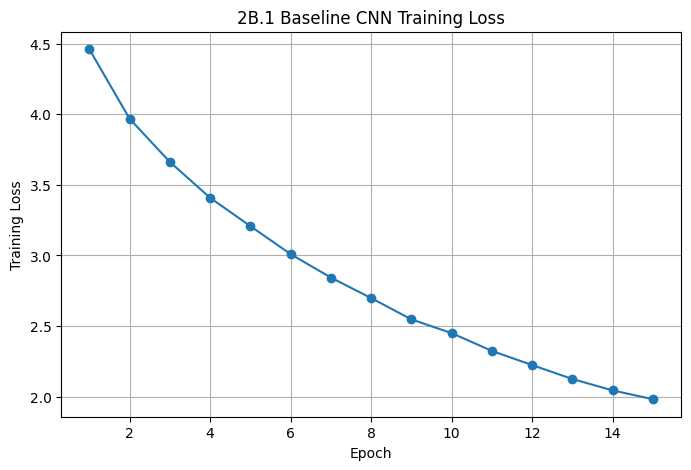

In [4]:
# =========================================
# 2B.1 Baseline CNN
# Train for 15 epochs and report training loss and test accuracy
# =========================================

baseline_model = BaselineCNN(num_classes=102).to(device)
print(baseline_model)

baseline_losses = train_model(
    baseline_model,
    train_loader_base,
    epochs=15,
    lr=1e-3
)

baseline_test_accuracy = compute_test_accuracy(baseline_model, test_loader_base)

print("\n===== 2B.1 RESULTS =====")
for i, loss in enumerate(baseline_losses):
    print(f"Epoch {i+1}: Training Loss = {loss:.4f}")
print(f"Final Test Accuracy = {baseline_test_accuracy:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(baseline_losses) + 1), baseline_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("2B.1 Baseline CNN Training Loss")
plt.grid(True)
plt.show()

In [5]:
# =========================================
# 2B.2 Mobile-Friendly CNN
# Compare parameter count, test accuracy, and compression ratio
# =========================================

baseline_model_2b2 = BaselineCNN(num_classes=102).to(device)
mobile_model_2b2 = MobileFriendlyCNN(num_classes=102).to(device)

baseline_params = count_params(baseline_model_2b2)
mobile_params = count_params(mobile_model_2b2)

print("\n===== 2B.2(a) PARAMETER COUNT =====")
print(f"Baseline CNN parameter count        : {baseline_params}")
print(f"Mobile-Friendly CNN parameter count : {mobile_params}")

print("\nTraining Baseline CNN for 2B.2")
baseline_losses_2b2 = train_model(
    baseline_model_2b2,
    train_loader_base,
    epochs=15,
    lr=1e-3
)

print("\nTraining Mobile-Friendly CNN for 2B.2")
mobile_losses_2b2 = train_model(
    mobile_model_2b2,
    train_loader_base,
    epochs=15,
    lr=1e-3
)

baseline_acc_2b2 = compute_test_accuracy(baseline_model_2b2, test_loader_base)
mobile_acc_2b2 = compute_test_accuracy(mobile_model_2b2, test_loader_base)

print("\n===== 2B.2(b) TEST ACCURACY =====")
print(f"Baseline CNN test accuracy        : {baseline_acc_2b2:.2f}%")
print(f"Mobile-Friendly CNN test accuracy : {mobile_acc_2b2:.2f}%")

if mobile_acc_2b2 >= baseline_acc_2b2 - 2.0:
    print("Conclusion: The mobile-friendly model maintains comparable accuracy.")
else:
    print("Conclusion: The mobile-friendly model does not maintain comparable accuracy; the drop is noticeable.")

actual_compression_ratio = baseline_params / mobile_params

# theoretical ratio from 2A.3 for one 32->64 layer
standard_conv_params = (64 * 32 * 3 * 3) + 64
depthwise_sep_params = (32 * 3 * 3 + 32) + (64 * 32 + 64)
theoretical_compression_ratio = standard_conv_params / depthwise_sep_params

print("\n===== 2B.2(c) COMPRESSION RATIO =====")
print(f"Actual whole-model compression ratio = {actual_compression_ratio:.4f}")
print(f"Theoretical compression ratio from 2A.3 = {theoretical_compression_ratio:.4f}")

if actual_compression_ratio < theoretical_compression_ratio:
    print("The actual whole-model compression ratio is lower than the theoretical layer-level ratio because only the last two blocks were factorized, while the first two blocks and classifier remain unchanged.")
elif actual_compression_ratio > theoretical_compression_ratio:
    print("The actual whole-model compression ratio is higher than the theoretical layer-level ratio.")
else:
    print("The actual and theoretical compression ratios are approximately the same.")


===== 2B.2(a) PARAMETER COUNT =====
Baseline CNN parameter count        : 415590
Mobile-Friendly CNN parameter count : 89830

Training Baseline CNN for 2B.2
Epoch [1/15] - Training Loss: 4.4313
Epoch [2/15] - Training Loss: 3.8994
Epoch [3/15] - Training Loss: 3.6022
Epoch [4/15] - Training Loss: 3.3650
Epoch [5/15] - Training Loss: 3.1658
Epoch [6/15] - Training Loss: 2.9682
Epoch [7/15] - Training Loss: 2.8484
Epoch [8/15] - Training Loss: 2.6969
Epoch [9/15] - Training Loss: 2.5240
Epoch [10/15] - Training Loss: 2.4312
Epoch [11/15] - Training Loss: 2.3150
Epoch [12/15] - Training Loss: 2.2480
Epoch [13/15] - Training Loss: 2.1317
Epoch [14/15] - Training Loss: 2.0342
Epoch [15/15] - Training Loss: 1.9359

Training Mobile-Friendly CNN for 2B.2
Epoch [1/15] - Training Loss: 4.5816
Epoch [2/15] - Training Loss: 4.1434
Epoch [3/15] - Training Loss: 3.8688
Epoch [4/15] - Training Loss: 3.6423
Epoch [5/15] - Training Loss: 3.4502
Epoch [6/15] - Training Loss: 3.2965
Epoch [7/15] - Train


Training Mobile-Friendly CNN WITHOUT augmentation
Epoch [1/15] - Training Loss: 4.6088
Epoch [2/15] - Training Loss: 4.1530
Epoch [3/15] - Training Loss: 3.8645
Epoch [4/15] - Training Loss: 3.6430
Epoch [5/15] - Training Loss: 3.4650
Epoch [6/15] - Training Loss: 3.2867
Epoch [7/15] - Training Loss: 3.1441
Epoch [8/15] - Training Loss: 3.0225
Epoch [9/15] - Training Loss: 2.8747
Epoch [10/15] - Training Loss: 2.7772
Epoch [11/15] - Training Loss: 2.6834
Epoch [12/15] - Training Loss: 2.5758
Epoch [13/15] - Training Loss: 2.4692
Epoch [14/15] - Training Loss: 2.4052
Epoch [15/15] - Training Loss: 2.3096

Training Mobile-Friendly CNN WITH augmentation
Epoch [1/15] - Training Loss: 4.6121
Epoch [2/15] - Training Loss: 4.2549
Epoch [3/15] - Training Loss: 3.9965
Epoch [4/15] - Training Loss: 3.8231
Epoch [5/15] - Training Loss: 3.6776
Epoch [6/15] - Training Loss: 3.5489
Epoch [7/15] - Training Loss: 3.4262
Epoch [8/15] - Training Loss: 3.3051
Epoch [9/15] - Training Loss: 3.1851
Epoch [

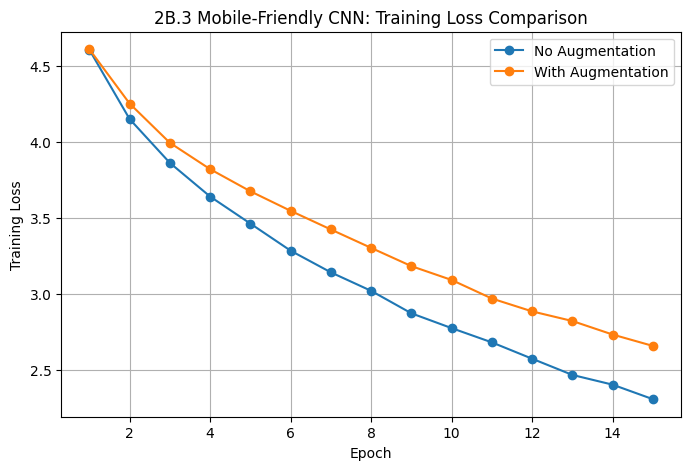


2B.3(b) Answer:
No, augmentation should not be applied to the test set.
The test set must remain fixed so that it provides a fair and consistent measure of generalization.
Applying augmentation to the test set changes the evaluation distribution and makes the reported accuracy harder to interpret.


In [6]:
# =========================================
# 2B.3 Data Augmentation Study
# Compare test accuracy with and without augmentation
# =========================================

train_transform_no_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_transform_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform_no_aug = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_data_no_aug = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform_no_aug,
    download=True
)

train_data_aug = datasets.Flowers102(
    root="./data",
    split="train",
    transform=train_transform_aug,
    download=True
)

test_data_no_aug = datasets.Flowers102(
    root="./data",
    split="test",
    transform=test_transform_no_aug,
    download=True
)

train_loader_no_aug = DataLoader(train_data_no_aug, batch_size=64, shuffle=True, num_workers=0)
train_loader_aug = DataLoader(train_data_aug, batch_size=64, shuffle=True, num_workers=0)
test_loader_no_aug = DataLoader(test_data_no_aug, batch_size=64, shuffle=False, num_workers=0)

print("\nTraining Mobile-Friendly CNN WITHOUT augmentation")
mobile_no_aug = MobileFriendlyCNN().to(device)
losses_no_aug = train_model(mobile_no_aug, train_loader_no_aug, epochs=15, lr=1e-3)
acc_no_aug = compute_test_accuracy(mobile_no_aug, test_loader_no_aug)

print("\nTraining Mobile-Friendly CNN WITH augmentation")
mobile_aug = MobileFriendlyCNN().to(device)
losses_aug = train_model(mobile_aug, train_loader_aug, epochs=15, lr=1e-3)
acc_aug = compute_test_accuracy(mobile_aug, test_loader_no_aug)

change_in_accuracy = acc_aug - acc_no_aug

print("\n===== 2B.3 RESULTS =====")
print(f"Test Accuracy without augmentation = {acc_no_aug:.2f}%")
print(f"Test Accuracy with augmentation    = {acc_aug:.2f}%")
print(f"Change in Test Accuracy            = {change_in_accuracy:+.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(losses_no_aug) + 1), losses_no_aug, marker='o', label='No Augmentation')
plt.plot(range(1, len(losses_aug) + 1), losses_aug, marker='o', label='With Augmentation')
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("2B.3 Mobile-Friendly CNN: Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("\n2B.3(b) Answer:")
print("No, augmentation should not be applied to the test set.")
print("The test set must remain fixed so that it provides a fair and consistent measure of generalization.")
print("Applying augmentation to the test set changes the evaluation distribution and makes the reported accuracy harder to interpret.")

Augmentation should not be applied to the test set. 

In [ ]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 4.4 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=3754f58d0ef3e3a4645e030da016426329e09114bc72839ff4b4cf4e344727ad
  Stored in directory: /home/ajoy/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [grad-cam]


Number of correctly classified samples selected: 3


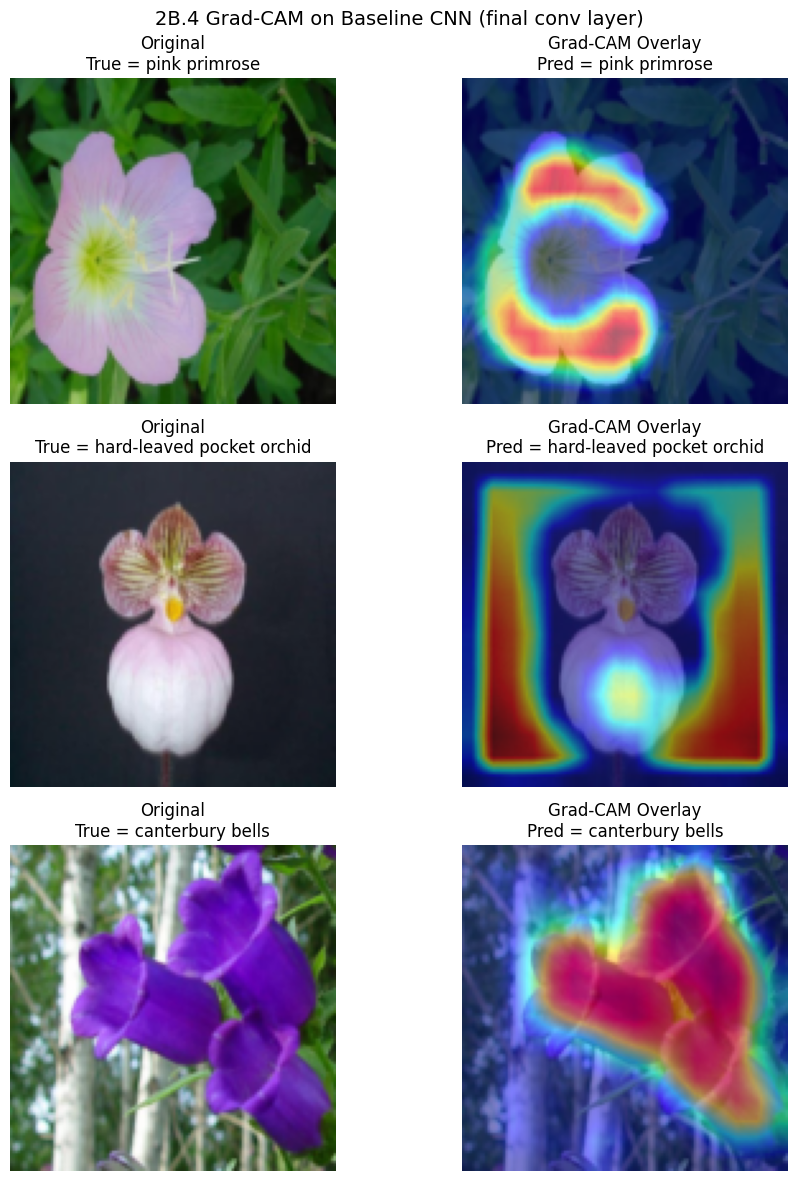


2B.4(c) Short analysis template:
The Grad-CAM maps show which image regions contributed most to the prediction.
For Flowers-102, the model often attends to petal structure, flower center, colour pattern, and overall blossom shape.
If attention is concentrated on the flower rather than the background, that suggests the model is learning meaningful class-specific cues.
You can now write 3–4 sentences based on the three overlays you obtained.


In [7]:
# =========================================
# 2B.4 Interpretability with Grad-CAM
# =========================================

# install once if needed
# !pip install grad-cam

import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

baseline_model.eval()

# final convolutional layer of baseline model
target_layers = [baseline_model.block4[0]]

# class names if available
class_names = getattr(test_data_base, "classes", None)
if class_names is None:
    class_names = [str(i) for i in range(102)]

# inverse normalization for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def denormalize(img):
    img = img.cpu() * std + mean
    img = torch.clamp(img, 0, 1)
    return img

# pick one correctly classified image from three different classes
selected_samples = []
seen_labels = set()

with torch.no_grad():
    for imgs, labels in test_loader_base:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = baseline_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        for i in range(imgs.size(0)):
            true_label = labels[i].item()
            pred_label = preds[i].item()

            if true_label == pred_label and true_label not in seen_labels:
                selected_samples.append((imgs[i].detach().cpu(), true_label, pred_label))
                seen_labels.add(true_label)

            if len(selected_samples) == 3:
                break

        if len(selected_samples) == 3:
            break

print(f"Number of correctly classified samples selected: {len(selected_samples)}")

fig, axes = plt.subplots(len(selected_samples), 2, figsize=(10, 4 * len(selected_samples)))

if len(selected_samples) == 1:
    axes = np.expand_dims(axes, axis=0)

with GradCAM(model=baseline_model, target_layers=target_layers) as cam:
    for row, (img_tensor_cpu, true_label, pred_label) in enumerate(selected_samples):
        input_tensor = img_tensor_cpu.unsqueeze(0).to(device)

        targets = [ClassifierOutputTarget(true_label)]
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

        rgb_img = denormalize(img_tensor_cpu).permute(1, 2, 0).numpy()
        cam_overlay = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        axes[row, 0].imshow(rgb_img)
        axes[row, 0].set_title(f"Original\nTrue = {class_names[true_label]}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(cam_overlay)
        axes[row, 1].set_title(f"Grad-CAM Overlay\nPred = {class_names[pred_label]}")
        axes[row, 1].axis("off")

plt.suptitle("2B.4 Grad-CAM on Baseline CNN (final conv layer)", fontsize=14)
plt.tight_layout()
plt.show()

print("\n2B.4(c) Short analysis template:")
print("The Grad-CAM maps show which image regions contributed most to the prediction.")
print("For Flowers-102, the model often attends to petal structure, flower center, colour pattern, and overall blossom shape.")
print("If attention is concentrated on the flower rather than the background, that suggests the model is learning meaningful class-specific cues.")
print("You can now write 3–4 sentences based on the three overlays you obtained.")

Best model selected: baseline_model
Best model test accuracy: 29.35%


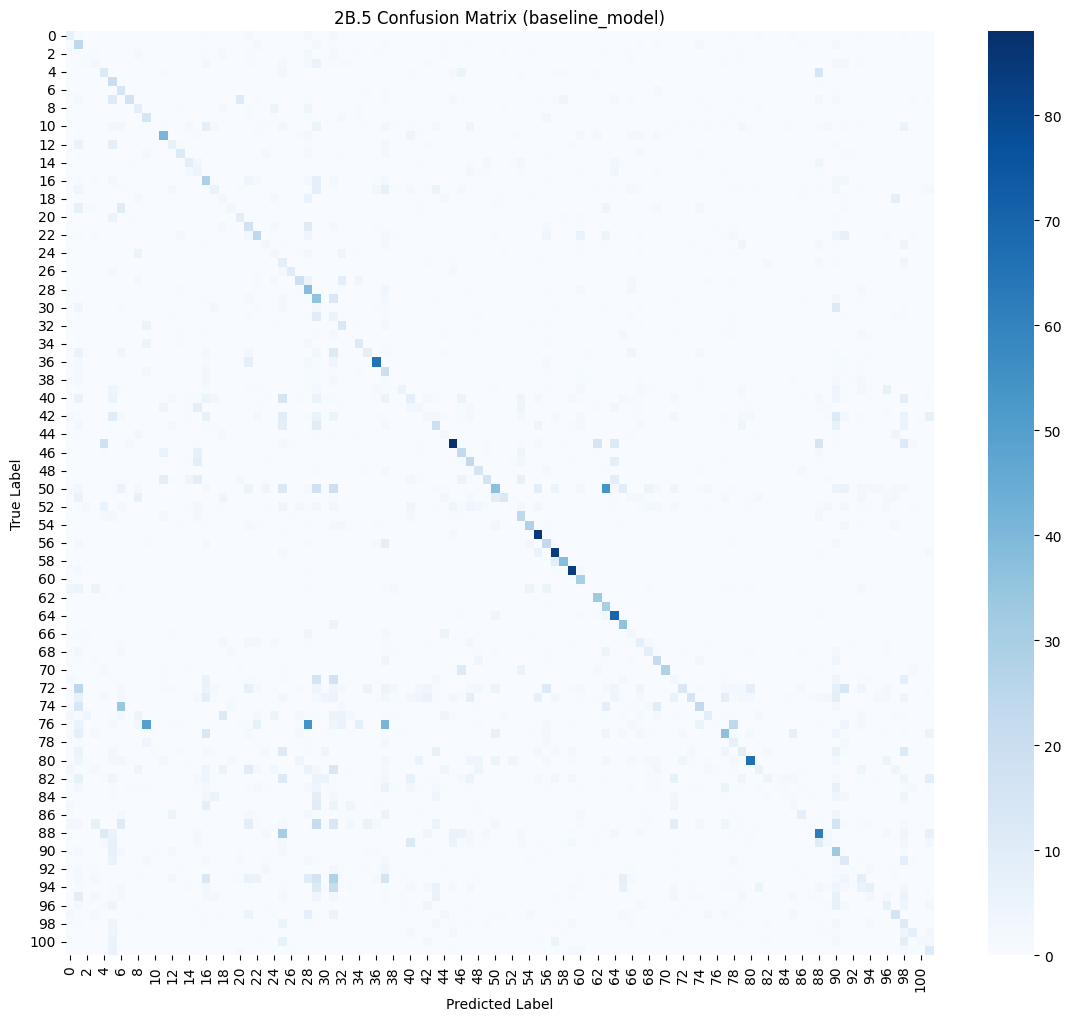


===== 2B.5(b) MOST CONFUSED CLASS PAIRS =====
1. petunia  <->  silverbush
   Total mutual confusion: 54
   petunia predicted as silverbush: 54
   silverbush predicted as petunia: 0
2. artichoke  <->  passion flower
   Total mutual confusion: 54
   artichoke predicted as passion flower: 54
   passion flower predicted as artichoke: 0

===== 2B.5(b) HYPOTHESIS =====
- petunia and silverbush may be confused because they share similar colour distribution, petal arrangement, and global flower shape at 128x128 resolution.
- artichoke and passion flower may be confused because they share similar colour distribution, petal arrangement, and global flower shape at 128x128 resolution.

===== 2B.5(c) TARGETED STRATEGY =====
A targeted strategy is to use tighter flower-centered crops or segmentation-based preprocessing so the model focuses more on petal structure and flower center details rather than background cues.
Another good option is class-specific hard-example mining for the most confused pa

In [8]:
# =========================================
# 2B.5 Confusion Matrix Analysis
# =========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix

# pick the best trained model automatically from the models already in your notebook
candidate_models = []

if "baseline_model" in globals() and "baseline_test_accuracy" in globals():
    candidate_models.append(("baseline_model", baseline_model, baseline_test_accuracy))

if "baseline_model_2b2" in globals() and "baseline_acc_2b2" in globals():
    candidate_models.append(("baseline_model_2b2", baseline_model_2b2, baseline_acc_2b2))

if "mobile_model_2b2" in globals() and "mobile_acc_2b2" in globals():
    candidate_models.append(("mobile_model_2b2", mobile_model_2b2, mobile_acc_2b2))

if "mobile_no_aug" in globals() and "acc_no_aug" in globals():
    candidate_models.append(("mobile_no_aug", mobile_no_aug, acc_no_aug))

if "mobile_aug" in globals() and "acc_aug" in globals():
    candidate_models.append(("mobile_aug", mobile_aug, acc_aug))

best_model_name, best_model, best_acc = max(candidate_models, key=lambda x: x[2])

print(f"Best model selected: {best_model_name}")
print(f"Best model test accuracy: {best_acc:.2f}%")

best_model.eval()

# class names if available
class_names = getattr(test_data_base, "classes", None)
if class_names is None:
    class_names = [str(i) for i in range(102)]

# gather predictions
all_true = []
all_pred = []

with torch.no_grad():
    for imgs, labels in test_loader_base:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = best_model(imgs)
        preds = torch.argmax(outputs, dim=1)

        all_true.extend(labels.cpu().numpy())
        all_pred.extend(preds.cpu().numpy())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

cm = confusion_matrix(all_true, all_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"2B.5 Confusion Matrix ({best_model_name})")
plt.show()

# find top 2 most confused unordered class pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

pairs = []
used_pairs = set()

flat_indices = np.argsort(cm_no_diag, axis=None)[::-1]

for idx in flat_indices:
    i, j = np.unravel_index(idx, cm_no_diag.shape)
    if cm_no_diag[i, j] == 0:
        break

    unordered_pair = tuple(sorted((i, j)))
    if i != j and unordered_pair not in used_pairs:
        total_confusion = cm[i, j] + cm[j, i]
        pairs.append((unordered_pair[0], unordered_pair[1], total_confusion, cm[i, j], cm[j, i]))
        used_pairs.add(unordered_pair)

    if len(pairs) == 2:
        break

print("\n===== 2B.5(b) MOST CONFUSED CLASS PAIRS =====")
for k, (a, b, total_confusion, ab, ba) in enumerate(pairs, start=1):
    print(f"{k}. {class_names[a]}  <->  {class_names[b]}")
    print(f"   Total mutual confusion: {total_confusion}")
    print(f"   {class_names[a]} predicted as {class_names[b]}: {ab}")
    print(f"   {class_names[b]} predicted as {class_names[a]}: {ba}")

print("\n===== 2B.5(b) HYPOTHESIS =====")
for a, b, total_confusion, ab, ba in pairs:
    print(f"- {class_names[a]} and {class_names[b]} may be confused because they share similar colour distribution, petal arrangement, and global flower shape at 128x128 resolution.")

print("\n===== 2B.5(c) TARGETED STRATEGY =====")
print("A targeted strategy is to use tighter flower-centered crops or segmentation-based preprocessing so the model focuses more on petal structure and flower center details rather than background cues.")
print("Another good option is class-specific hard-example mining for the most confused pair so the model sees more examples that directly distinguish those two classes.")